In [17]:
import pandas as pd
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, RepeatVector, TimeDistributed 
from sklearn.metrics import classification_report

from collections import Counter
from sklearn.datasets import make_classification

In [3]:
df = pd.read_csv(r"C:\Users\shaik\OneDrive\Desktop\Pyton Class\Data set\Nifty closing price\spx.csv", parse_dates=['date'], index_col='date') 

df.head()

,close
date,
1986-01-02,209.59
1986-01-03,210.88
1986-01-06,210.65
1986-01-07,213.80
1986-01-08,207.97


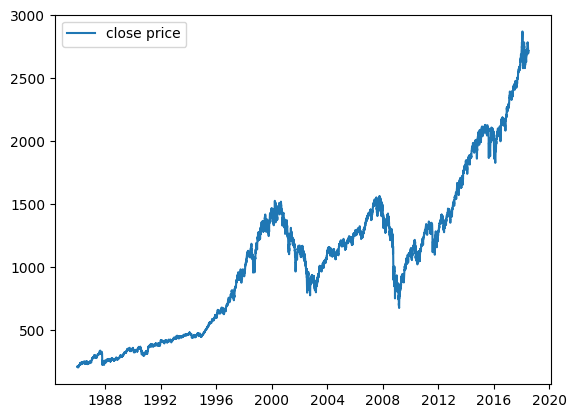

In [4]:
plt.plot(df, label='close price') 
plt.legend()

In [15]:
dk=pd.get_dummies(df)

In [16]:
dk

,close
date,
1986-01-02,209.59
1986-01-03,210.88
1986-01-06,210.65
1986-01-07,213.80
1986-01-08,207.97
...,...
2018-06-25,2717.07
2018-06-26,2723.06
2018-06-27,2699.63


In [17]:
x= dk.drop(['close'],axis=1)
y= dk['close']

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=40)

In [8]:
train_size = int(len(df) * 0.95)
test_size = len(df) - train_size
train, test = df.iloc[0:train_size], df.iloc[train_size:len(df)] 
print(train.shape, test.shape)
scaler = StandardScaler()
scaler = scaler.fit(train[['close']])
train['close'] = scaler.transform(train[['close']]) 
test['close'] = scaler.transform(test[['close']])

(7782, 1) (410, 1)


C:\Users\shaik\AppData\Local\Temp\ipykernel_2096\577729666.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['close'] = scaler.transform(train[['close']])
C:\Users\shaik\AppData\Local\Temp\ipykernel_2096\577729666.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['close'] = scaler.transform(test[['close']])


In [9]:
def create_seq(X, y, time_steps=1): 
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values 
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

In [13]:
TIME_STEPS = 30

In [14]:
X_train, y_train = create_seq(train[['close']], train.close, TIME_STEPS)
X_test, y_test = create_seq(test[['close']], test.close, TIME_STEPS)

In [23]:
keras = tf.keras

In [24]:
model = tf.keras.models.Sequential() 
model.add(keras.layers.LSTM(units=64,input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(keras.layers.Dropout(rate=0.2)) 
model.add(keras.layers.RepeatVector(n=X_train.shape[1])) 
model.add(keras.layers.LSTM(units=64, return_sequences=True)) 
model.add(keras.layers.Dropout(rate=0.2))
model.add(keras.layers.TimeDistributed( keras.layers.Dense(units=X_train.shape[2])))

model.compile(loss='mae', optimizer='adam')

In [25]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 repeat_vector (RepeatVecto  (None, 30, 64)            0         
 r)                                                              
                                                                 
 lstm_1 (LSTM)               (None, 30, 64)            33024     
                                                                 
 dropout_1 (Dropout)         (None, 30, 64)            0         
                                                                 
 time_distributed (TimeDist  (None, 30, 1)             65        
 ributed)                                             

In [26]:
history = model.fit( X_train, y_train, epochs=10, batch_size=32, 
                    validation_split=0.1, shuffle=False)

Epoch 1/10

218/218 [==============================] - 16s 45ms/step - loss: 0.1667 - val_loss: 0.2380
Epoch 2/10
218/218 [==============================] - 6s 30ms/step - loss: 0.1017 - val_loss: 0.1802
Epoch 3/10
218/218 [==============================] - 8s 35ms/step - loss: 0.1016 - val_loss: 0.1752
Epoch 4/10
218/218 [==============================] - 6s 27ms/step - loss: 0.1091 - val_loss: 0.1890
Epoch 5/10
218/218 [==============================] - 6s 27ms/step - loss: 0.1208 - val_loss: 0.2666
Epoch 6/10
218/218 [==============================] - 6s 28ms/step - loss: 0.1076 - val_loss: 0.3138
Epoch 7/10
218/218 [==============================] - 5s 25ms/step - loss: 0.1063 - val_loss: 0.3113
Epoch 8/10
218/218 [==============================] - 6s 27ms/step - loss: 0.1212 - val_loss: 0.2505
Epoch 9/10
218/218 [==============================] - 6s 27ms/step - loss: 0.1133 - val_loss: 0.1679
Epoch 10/10
218/218 [==============================] - 5s 25ms/step - loss: 0.1172 - val_

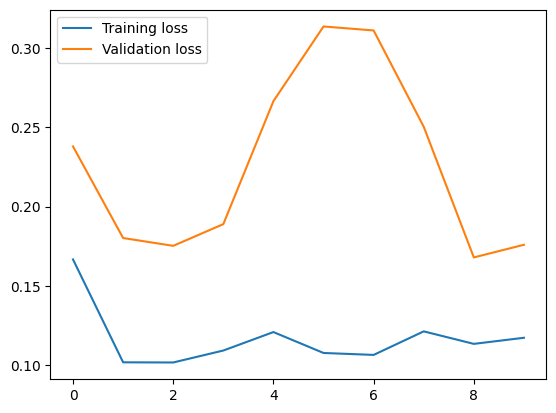

In [27]:
plt.plot(history.history['loss'], label='Training loss') 
plt.plot(history.history['val_loss'], label='Validation loss') 
plt.legend()

In [28]:
model.evaluate(X_test, y_test)

12/12 [==============================] - 0s 12ms/step - loss: 0.6501


0.650145411491394

In [29]:
X_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=1)

243/243 [==============================] - 3s 7ms/step


C:\Users\shaik\AppData\Local\Temp\ipykernel_2096\4276719448.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_mae_loss, bins=50, kde=True)


<AxesSubplot: ylabel='Density'>

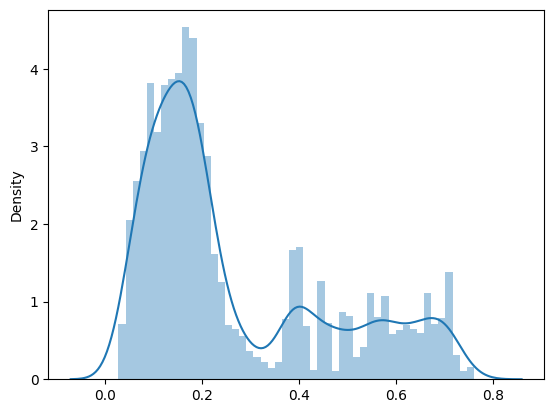

In [30]:
sns.distplot(train_mae_loss, bins=50, kde=True)

In [39]:
THRESHOLD = 0.75
X_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=1)

12/12 [==============================] - 0s 7ms/step


In [40]:
test_score_df = pd.DataFrame(index=test[TIME_STEPS:].index) 
test_score_df['loss'] = test_mae_loss
test_score_df['threshold'] = THRESHOLD
test_score_df['anomaly'] = test_score_df.loss > test_score_df.threshold 
test_score_df['close'] = test[TIME_STEPS:].close

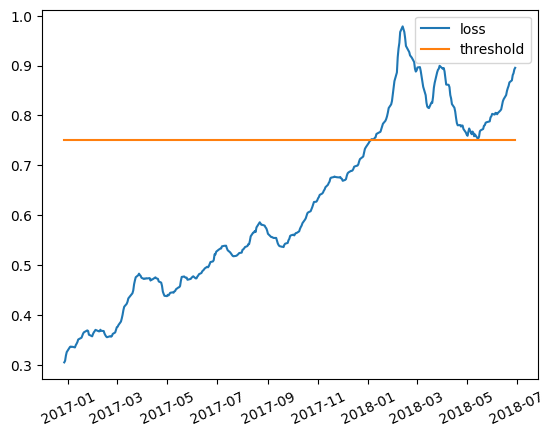

In [41]:
plt.plot(test_score_df.index, test_score_df.loss, label='loss') 
plt.plot(test_score_df.index, test_score_df.threshold, label='threshold') 
plt.xticks(rotation=25)
plt.legend()

In [42]:
anomalies = test_score_df[test_score_df.anomaly == True] 
anomalies.head()

,loss,threshold,anomaly,close
date,,,,
2018-01-05,0.752320,0.75,True,3.283632
2018-01-08,0.752299,0.75,True,3.292197
2018-01-09,0.755035,0.75,True,3.298922
2018-01-10,0.756033,0.75,True,3.293174
2018-01-11,0.762733,0.75,True,3.329481


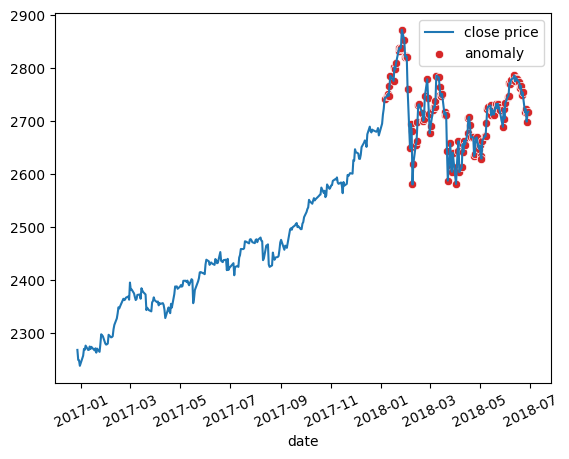

In [43]:
anomalies_close = anomalies[["close"]].values.flatten()
anomalies_close = anomalies_close.reshape(-1, 1) # Reshape to a 2D array
anomalies_close = scaler.inverse_transform(anomalies_close)

plt.plot(test[TIME_STEPS:].index, 
         scaler.inverse_transform(test[TIME_STEPS:][["close"]]), 
         label='close price')

# convert it to a 1D array for the plot
anomalies_close = anomalies_close.flatten()
sns.scatterplot(x=anomalies.index, 
                y=anomalies_close, 
                color=sns.color_palette()[3], 
                label='anomaly'
               )

plt.xticks(rotation=25) 
plt.legend()